In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
corrdone=False

In [3]:
from pyCHX.chx_packages import *
%matplotlib notebook
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({ 'image.origin': 'lower'   })
plt.rcParams.update({ 'image.interpolation': 'none'   })
import pickle as cpk
from pyCHX.chx_xpcs_xsvs_jupyter_V1 import *

from skbeam.core.roi import segmented_rings, ring_edges
from skbeam.core.utils import radial_grid, angle_grid
from skimage.draw import line_aa, line, polygon, ellipse, disk


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, plot, imshow
%matplotlib notebook

from pyCHX.chx_packages import *
from pyCHX.chx_xpcs_xsvs_jupyter_V1 import *

import json  ### NEW for auto_masking

%run /nsls2/data/chx/legacy/analysis/2022_3/lwiegart/development/chx_analysis_setup.ipynb


Tiled version 0.1.0a120
/nsls2/conda/envs/2024-2.0-py311-tiled/lib/python3.11/site-packages/databroker/v1.py:72: UserWarning: In databroker 2.x, there are separate notions of 'server' and 'client', and register_handler(...) has no effect on the client. Likely this is being done for you on the server side, so you should not worry about this message unless you encounter trouble loading large array data.
  warnings.warn(


running on: jupyter_hub   environment: standard
setting '_base_path_' as /nsls2/data/chx/legacy/analysis/
setting '_mask_path_' as /nsls2/data/chx/shared/CHX_Setup/Detector_masks/
ran "%run -i /nsls2/data/chx/legacy/analysis/2022_3/lwiegart/development/roi_nr_2019_3_0_1.py" to fix ROI numbering for PHI-sliced data sets. Should get fixed in pyCHX...
ran "%run -i /nsls2/data/chx/legacy/analysis/2023_2/lwiegart/pyCHX_June2023/chx_outlier_detection.py": this should become part of pyCHX.
ran "%run -i /nsls2/data/chx/legacy/analysis/2023_2/lwiegart/pyCHX_June2023/fix_get_sid_filenames.py": this should be fixed and re-deployed in pyCHX.

environment dependent settings and patches:
using "%matplotlib inline" for plotting
ran "%run -i /nsls2/data/chx/legacy/analysis/2022_3/lwiegart/development/polygonmask_fix.py".
ran "%run -i /nsls2/data/chx/legacy/analysis/2023_2/lwiegart/pyCHX_June2023/chx_compress.py": temporary fix for depreciated np.float.
ran "%run -i /nsls2/data/chx/legacy/analysis/2023

In [4]:
scat_geometry = 'saxs'

In [5]:
scan_nr=147260

h=db[scan_nr]
uid=h.start['uid']
print('uid: %s'%uid)

uid: 269baebb-a613-43ff-8eab-3e71e636e1d2


In [6]:
#uid = '445b9d' #(scan num: 135097)
    
uidstr = 'uid=%s'%uid[:6]
print(uidstr)

dscan = True #True #False #  True #False
count = not dscan #True #False #True

uid=269bae


In [7]:
cycle= '2024_1'  #change clycle here
default_dir = _base_path_
path = default_dir + '%s/masks/'%cycle
username = 'leheny'

data_dir0  = create_user_folder(cycle, username, default_dir=default_dir)
print( data_dir0 )
uid = uid[:8]
print('The current uid for analysis is: %s...'%uid)

mask_path =default_dir+'%s/%s/masks/'%(cycle,username)


Results from this analysis will be stashed in the directory /nsls2/data/chx/legacy/analysis/2024_1/leheny/Results/
/nsls2/data/chx/legacy/analysis/2024_1/leheny/Results/
The current uid for analysis is: 269baebb...


## Load data and ROI

In [8]:
if dscan:## This works for dscan with each motor position having multi frames
    imgs =  np.array(db.get_images(db[uid], 'eiger4m_single_image'))
    #pixel_mask = imgs[0].md['binary_mask']
    #md = imgs[0].md
    md = get_meta_data( uid )
    
    #data = db[uid]
    #detector = get_detector(data)
    #imgs = np.array(db.get_images(fig,ax = plt.subplots(1,3,figsize=(15,5))

    
    
else:
    #imgs =  db.get_images(db[uid], 'eiger1m_single_image')
    md = get_meta_data( uid )
    sud = get_sid_filenames(db[uid])
    for pa in sud[2]:
        if 'master.h5' in pa:
            data_fullpath = pa

    detectors = sorted(get_detectors(db[uid]))
    print('The detectors are:%s'%detectors)
    if len(detectors) >1:
        md['detector'] = detectors[1]
        print( md['detector'])
    if md['detector'] =='eiger4m_single_image' or md['detector'] == 'image':    
        reverse= True
        rot90= False
    elif md['detector'] =='eiger500K_single_image':    
        reverse= True
        rot90=True
    elif md['detector'] =='eiger1m_single_image':    
        reverse= True
        rot90=False
    print('Image reverse: %s\nImage rotate 90: %s'%(reverse, rot90))            
    try:
        cx , cy = md_blue['beam_center_x'], md_blue['beam_center_y']
        print(cx,cy)
    except:
        print('Will find cx,cy later.')  

    imgs = load_data( uid, 'eiger4m_single_image', reverse= reverse, rot90=rot90  )
    #md = imgs.md
    md.update( imgs.md );Nimg = len(imgs);
    pixel_mask = md['binary_mask']    
    
    if scat_geometry =='gi_saxs':
        inc_x0 =  md['beam_center_x'] 
        inc_y0 =  imgs[0].shape[0] - md['beam_center_y']     

        refl_x0 =     md['beam_center_x']  
        refl_y0 =     imgs[0].shape[0] - 673   

        print( "inc_x0, inc_y0, ref_x0,ref_y0 are: %s %s %s %s."%(inc_x0, inc_y0, refl_x0, refl_y0) )
    else:
        if md['detector'] =='eiger4m_single_image' or md['detector'] == 'image' or md['detector']=='eiger1m_single_image':    
            inc_x0 =  imgs[0].shape[0] - md['beam_center_y']   
            inc_y0=   md['beam_center_x']
        elif md['detector'] =='eiger500K_single_image':    
            inc_y0 =  imgs[0].shape[1] - md['beam_center_y']   
            inc_x0 =   imgs[0].shape[0] - md['beam_center_x']

        print(inc_x0, inc_y0)    
    
    
    dpix, lambda_, Ldet,  exposuretime, timeperframe, center = check_lost_metadata(
    md, Nimg, inc_x0 = inc_x0, inc_y0=   inc_y0, pixelsize = 7.5*10*(-5) )
    if scat_geometry =='gi_saxs':center=center[::-1]

    setup_pargs=dict(uid=uidstr, dpix= dpix, Ldet=Ldet, lambda_= lambda_, exposuretime=exposuretime,
            timeperframe=timeperframe, center=center, path= data_dir)
    print_dict( setup_pargs )
    
Nimg = len(imgs);
#if 'number of images'  not in list(md.keys()):
md['number of images']  = Nimg
print( 'The data are: %s' %str(imgs.shape) )
print('metadata: %s'%str(md).split(","))

More than one device. This would have unintented consequences.Currently, only the device contains 'default_dec=eiger'.
The data are: (21, 1, 2167, 2070)
metadata: ["{'suid': '269baebb'", " 'filename': '/nsls2/data/chx/legacy/data/2024/04/05/98ce8600-38d6-4f81-a0b0_929_data_000001.h5'", " 'detector': 'eiger4m_single_image'", " 'eiger4m_single_cam_acquire_period': 0.01", " 'eiger4m_single_cam_acquire_time': 0.009997", " 'eiger4m_single_cam_num_images': 1", " 'eiger4m_single_beam_center_x': 1155.0", " 'eiger4m_single_beam_center_y': 1231.0", " 'eiger4m_single_wavelength': 0.969080806887606", " 'eiger4m_single_det_distance': 16.033868610000003", " 'eiger4m_single_threshold_energy': 6397.0", " 'eiger4m_single_photon_energy': 12794.0", " 'eiger4m_single_stats1_bgd_width': 1", " 'eiger4m_single_stats1_centroid_threshold': 1.0", " 'eiger4m_single_stats1_compute_centroid': 'No'", " 'eiger4m_single_stats1_compute_histogram': 'No'", " 'eiger4m_single_stats1_compute_profiles': 'No'", " 'eiger4m_si

In [9]:
str(md).split(",")

["{'suid': '269baebb'",
 " 'filename': '/nsls2/data/chx/legacy/data/2024/04/05/98ce8600-38d6-4f81-a0b0_929_data_000001.h5'",
 " 'detector': 'eiger4m_single_image'",
 " 'eiger4m_single_cam_acquire_period': 0.01",
 " 'eiger4m_single_cam_acquire_time': 0.009997",
 " 'eiger4m_single_cam_num_images': 1",
 " 'eiger4m_single_beam_center_x': 1155.0",
 " 'eiger4m_single_beam_center_y': 1231.0",
 " 'eiger4m_single_wavelength': 0.969080806887606",
 " 'eiger4m_single_det_distance': 16.033868610000003",
 " 'eiger4m_single_threshold_energy': 6397.0",
 " 'eiger4m_single_photon_energy': 12794.0",
 " 'eiger4m_single_stats1_bgd_width': 1",
 " 'eiger4m_single_stats1_centroid_threshold': 1.0",
 " 'eiger4m_single_stats1_compute_centroid': 'No'",
 " 'eiger4m_single_stats1_compute_histogram': 'No'",
 " 'eiger4m_single_stats1_compute_profiles': 'No'",
 " 'eiger4m_single_stats1_compute_statistics': 'Yes'",
 " 'eiger4m_single_stats1_hist_max': 255.0",
 " 'eiger4m_single_stats1_hist_min': 0.0",
 " 'eiger4m_singl

In [10]:
%run  -i pstorage/scan-yh-1.des.py

[]


In [11]:
# #check information in file header
# DD.FD.FID.seek(0,0)
# buf=DD.FD.FID.read(1024)
# DD.FD.prheader(buf)

In [12]:
imgs=np.squeeze(imgs)[:,::-1,:]

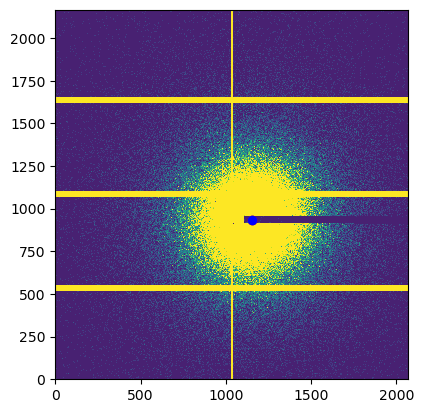

In [13]:
figure()
plt.imshow(imgs[0,:,:],vmin=-1,vmax=10)
plt.plot(DD.DD['xbar'],DD.DD['ybar'],'ro')
#beam_center_x 1112.0
#beam_center_y 1224.0
# plot(1112,2167-1224,'bo')
plot(1155,2167-1231,'bo')

In [14]:
DD.DD

{'pdir': '/nsls2/data/chx/legacy/analysis/2024_1/leheny/',
 'cdir': '',
 'firstfile': 1,
 'filename': 'uid_scan-yh-1.cmp',
 'FOUT': 'scan-yh-1',
 'xbar': 1155.0,
 'ybar': 936.0,
 'numberfiles': 20,
 'detector': 'Eiger-4M',
 'dpix': 0.075,
 'mask': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 1., ..., 1., 1., 0.],
        [0., 1., 1., ..., 1., 1., 0.],
        ...,
        [0., 1., 1., ..., 1., 1., 0.],
        [0., 1., 1., ..., 1., 1., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 'ccdroi': [1, 2167, 2070],
 'rows': 2167,
 'cols': 2070,
 'energy': 12.803566422662117,
 'rdet': 16035.451415000001,
 'compression': 6,
 'preset': 0.009997,
 'preset_period': 0.01,
 'qperpixel': 3.0348642397261665e-05}

In [15]:
if  dscan:
    #center = [936, 1147]
    center= [2167-DD.DD['xbar'],DD.DD['ybar']]
    #md = imgs[0].md
    md['detector'] ='eiger4m_single_image'
    #dpix, Ldet,lambda_ = 0.075, 16035.64,   1.284411
    dpix, Ldet,lambda_ = 0.075, 16035.64,0.96560895
    timeperframe = 0.01
    exposuretime = timeperframe
    setup_pargs=dict(uid=uidstr, dpix= dpix, Ldet=Ldet, lambda_= lambda_, exposuretime=exposuretime,
            timeperframe=timeperframe, center=center, path= data_dir0)

    
        
        

# Partition into bins

In [16]:
from fitcorrs import *#read in routines
from pyanal.partitions import mkpartlist,partition1d,partition2d
from pyanal.mkphiq import mkphiq
from pyanal.crosscor import *
from pyanal.ldparts import *
from pyanal.h2t import h2t
from pyanal.avgg2 import avgg2
from pyanal.ciravg import *
import scipy.signal
from numpy import r_


In [17]:
pixellist,qs,phis=mkphiq(DD,phimin=-10)
avgimg=np.mean(imgs,axis=0)*mask
Q,S=ciravg(avgimg,pixellist,qs,np.arange(45,1000))
SG=np.interp(qs,Q,S)

nopixels = 4105664 (91.53%)
minimum q =  22.0 maximum q =  1685.869805174765
phi discontinuity is at   -10.0000,  350.0000
minimum phi=  -9.999919055924295 maximum phi 349.99991544165505


In [18]:
qlist=mkpartlist(np.linspace(25,505,20))
philist=mkpartlist(np.arange(0,360,22.5),width=20)
plist,bind,qbind,phibind,noperbin,inpixellist,binlist,binqlist,binphilist=\
    partition2d(pixellist,qs,qlist,phis,philist,thres=100)

In [19]:
qavg=np.bincount(bind,weights=qs[inpixellist])/noperbin
phiavg=np.bincount(bind,weights=phis[inpixellist])/noperbin

In [20]:
px=qavg*np.cos(phiavg/57.3)+DD.DD['xbar']
py=qavg*np.sin(phiavg/57.3)+DD.DD['ybar']

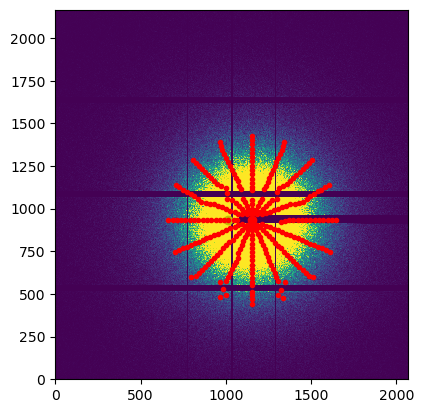

In [21]:
plt.figure()
timg=0*avgimg
timg.ravel()[plist]=phis[inpixellist]
plt.imshow(avgimg,vmax=10)
plt.plot(center[0],center[1],'yo')
plt.plot(px,py,'r.')
plt.plot(DD.DD['xbar'],DD.DD['ybar'],'ro')

[12.63157895 12.63157895 12.63157895 12.63157895 12.63157895 12.63157895
 12.63157895 12.63157895 12.63157895 12.63157895 12.63157895 12.63157895
 12.63157895 12.63157895 12.63157895 12.63157895 12.63157895 12.63157895
 12.63157895]


Text(0.5, 0, 'Q (pixels)')

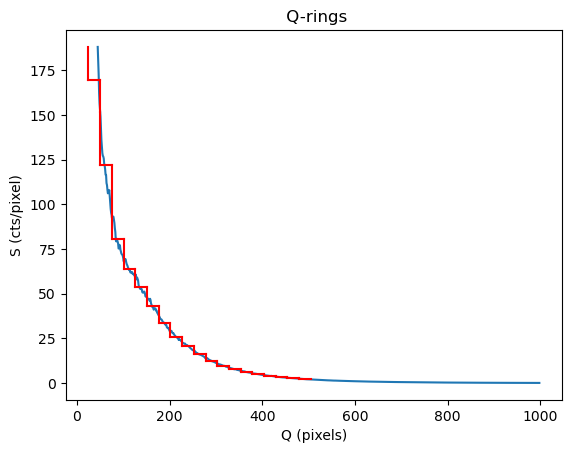

In [22]:
plt.figure()
plt.plot(Q,S)
# for i in range(len(qlist)/2):
#     plot()
sp=np.interp(qlist,Q,S)
spm=(sp[::2]+sp[1::2])/2.0
dq=(qlist[1::2]-qlist[::2])/2
print(dq)
for i in range(len(spm)):
    plt.plot(qlist[[2*i,2*i]],r_[sp[2*i],spm[i]],'r')
    plt.plot(qlist[2*i:2*i+2],r_[spm[i],spm[i]],'r')
    plt.plot(qlist[[2*i+1,2*i+1]],r_[spm[i],sp[2*i+1]],'r')
plt.title(" Q-rings")
plt.ylabel("S (cts/pixel)")
plt.xlabel("Q (pixels)")

In [23]:
n=imgs.shape[0]
Ipix=np.zeros((n,len(plist)))
for i in range(n):
    Ipix[i,:]=imgs[i,:,:].ravel()[plist]
print(Ipix.shape,plist.shape)

(21, 610380) (610380,)


In [24]:
from pyanal.crosscor import *

In [25]:
ii=np.zeros_like(avgimg,dtype=np.int64)
ii.ravel()[plist]=1+bind
CC=crosscor(ii.shape,ii,normalization="symavg")

100%|██████████| 290/290 [00:00<00:00, 1314.93it/s]


In [26]:
f1,f2=[5,7]
%time res=CC(imgs[f1,:,:],imgs[f2,:,:])

CPU times: user 653 ms, sys: 8.67 ms, total: 661 ms
Wall time: 660 ms


1.125208753832912


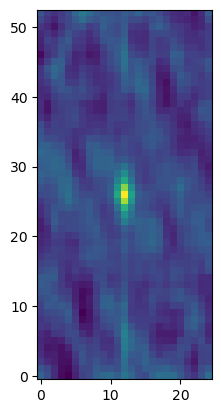

In [27]:
binno=60
figure()
plt.imshow(res[binno])
print(np.max(res[binno]))

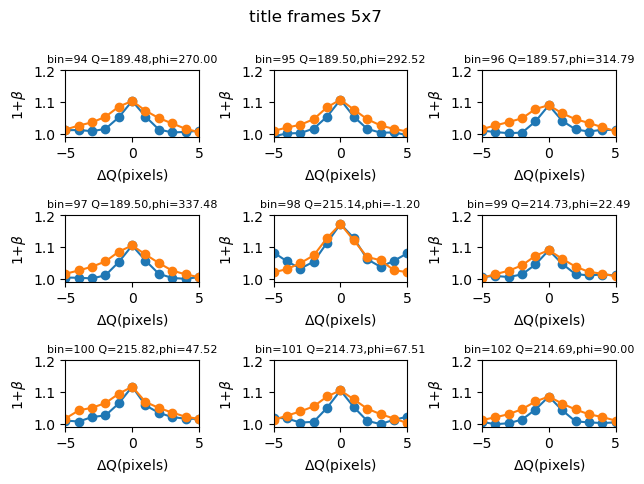

In [28]:
fig,ax=plt.subplots(3,3)
ax=ax.ravel()
for i,binno in enumerate(r_[np.arange(9)]+3+13*7):
    ci,cj=CC.centers[binno]
    ax[i].plot(np.arange(res[binno].shape[1])-cj,res[binno][ci,:],'o-')
#     ax[binno//2].plot(ci,1,'o')
    ax[i].plot(np.arange(res[binno].shape[0])-ci,res[binno][:,cj],'o-')
#     ax[binno//2].plot(cj,1,'o')
    ax[i].set_ylim(.99,1.2)
    ax[i].set_xlim(-5,5)
    ax[i].set_xlabel("$\Delta$Q(pixels)")
    ax[i].set_ylabel(r"1+$\beta$")
    ax[i].set_title("bin={:d} Q={:.2f},phi={:.2f}".\
                format(binno,qavg[binno],phiavg[binno]),fontsize=8)
plt.suptitle("{:s} frames {:d}x{:d}".format("title",f1,f2),y=1.0)
plt.tight_layout()

In [29]:
binno=93

In [30]:
from fitcorrs import *
from trifn import *

In [31]:
cx,cy=CC.centers[binno]
print(cx,cy)
print(qavg[binno],phiavg[binno])

23 35
189.4972030434027 247.4840480936163


In [32]:
chisq,afit,sigmaa,beta0=fitonecorr(CC.centers[binno],CC.sizes[binno],\
        res[binno],"bin {:d}".format(binno),fn_name=trifn,testing=True,cvfit=True)

In [33]:
print(chisq,afit)

0.39259462076263296 [ 0.09067506 -0.09528066  0.09044188  2.05168967  1.17605597  1.00153799]


In [34]:
afit[1:3]+=(cx,cy)
m=trifn(np.indices(res[binno].shape),afit).reshape(res[binno].shape)

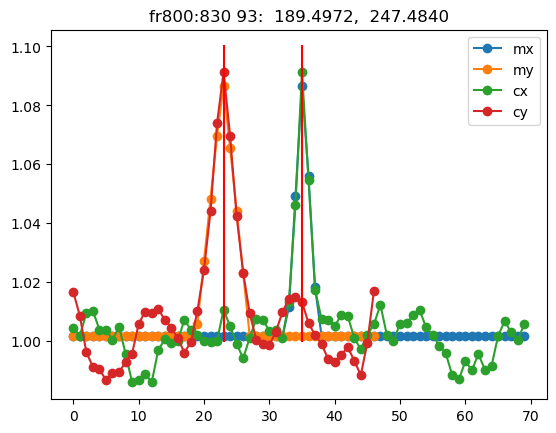

In [35]:
figure()
plot(m[cx,:],'o-',label='mx')
plot(m[:,cy],'o-',label='my')
# plot(m[:,cy+1],'o-',label='my+1')
plot(res[binno][cx,:],'o-',label='cx')
plot(res[binno][:,cy],'o-',label='cy')
# plot(res0[binno][:,cy+1],'o-',label='cy+1')
# plot(1+3*(restot1[binno][cx,:]-1),'o-')
# plot(1+3*(restot1[binno][:,cy]-1),'o-')
plot([cx,cx],[1,1.1],'r')
plot([cy,cy],[1,1.1],'r')
plt.title("fr800:830 {:d}:{:10.4f},{:10.4f}".format(binno,qavg[binno],phiavg[binno]))
plt.legend()

In [36]:
r,re=fitcorrs(CC,res,'5--10',fn_name=trifn,cvfit=True)

100%|██████████| 290/290 [00:01<00:00, 171.56it/s]


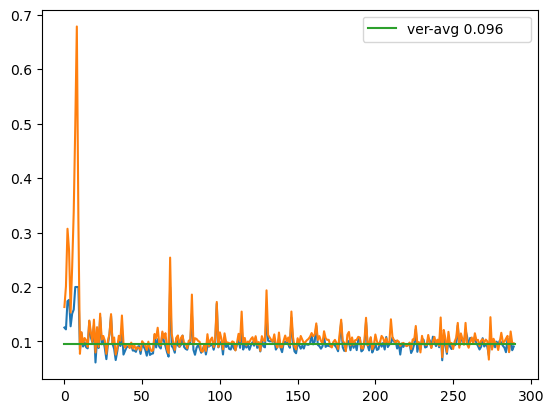

In [37]:
figure()
plot(r[:,1])
plot(r[:,-1]-1.0)
# plt.ylim(0,.5)
xavg=np.mean(r[100:200,:],axis=0)[1]
plot([0,r.shape[0]],[xavg,xavg],label="ver-avg {:<10.3f}".format(xavg))
plt.legend()
# plt.ylim(0,.5)

In [38]:
print(np.mean(r[100:,1]))

0.09563420376232308


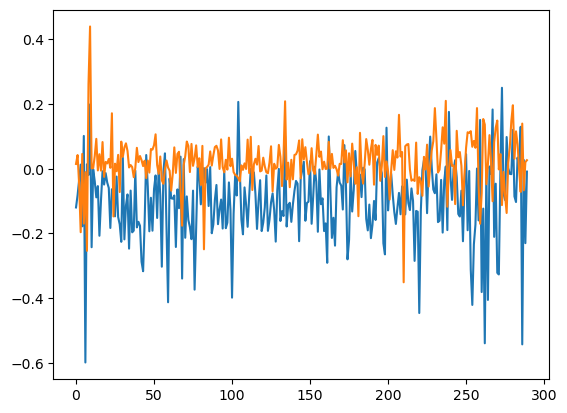

In [39]:
figure()
plot(r[:,2])
plot(r[:,3])

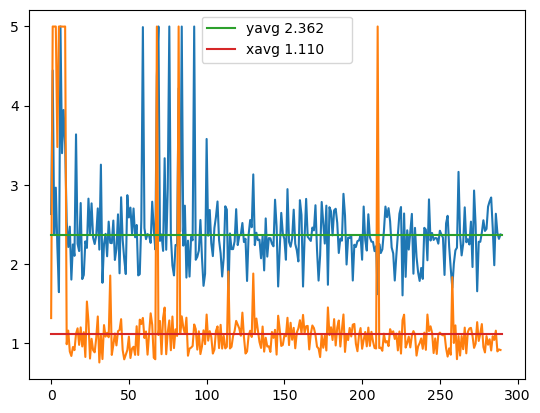

In [40]:
figure()
xavg,yavg=np.mean(r[100:200,:],axis=0)[[4,5]]
# plot(r[:,0])
plot(r[:,4])
plot(r[:,5])
# plt.ylim(-.5,1.1)
plot([0,r.shape[0]],[xavg,xavg],label="yavg {:<10.3f}".format(xavg))
plot([0,r.shape[0]],[yavg,yavg],label="xavg {:<10.3f}".format(yavg))
plt.legend()

In [41]:
print(np.mean(r[50:,:],axis=0),xavg,yavg)

[ 8.68542221  0.09547041 -0.09620355  0.02055493  2.40211418  1.12888441
  1.00111637  1.10311326] 2.361662306469782 1.1102050663791385


In [42]:
np.where(r[:,2]<-2)[0]

array([], dtype=int64)

In [43]:
%run -i wedges.py

<Figure size 640x480 with 0 Axes>

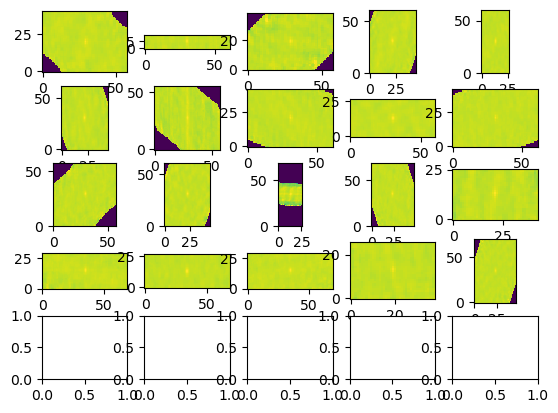

In [44]:
fig,ax=plt.subplots(5,5)
ax=ax.ravel()
for i,bi in enumerate(range(70,90)):
    ax[i].imshow(res[bi],vmax=1.1,vmin=0)

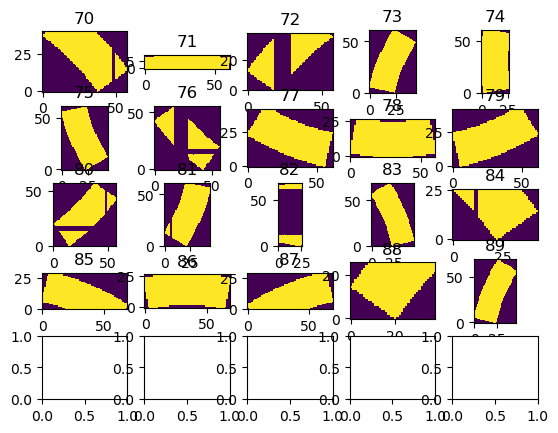

In [45]:
ll=wedges(CC,imgs[f1,:,:])
fig,ax=plt.subplots(5,5)
ax=ax.ravel()
for i,bi in enumerate(range(70,90)):
    ax[i].imshow(ll[bi],vmax=2,vmin=0)
    ax[i].set_title("{:d}".format(bi))
# plt.tight_layout()

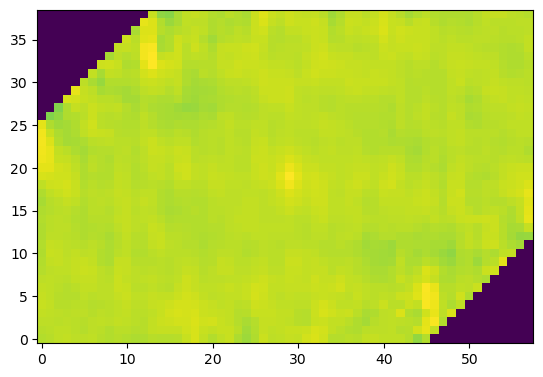

In [46]:
plt.figure()
plt.imshow(res[72])

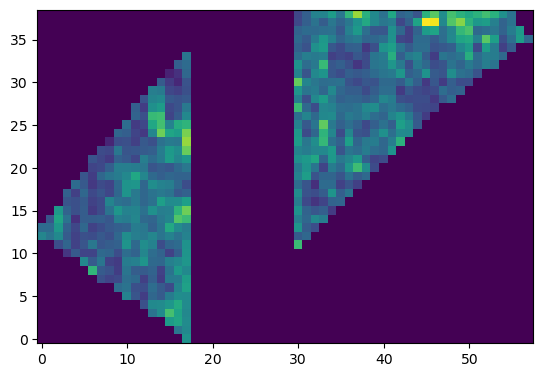

In [47]:
plt.figure()
plt.imshow(ll[72])

In [48]:
DIR="pstorage/scan-xh-1/"
if not corrdone: res,reserr=fitframes(1+np.arange(18),1+np.arange(18)+2,CC,DD,DIR=DIR,outflag=True)
if not corrdone: res,reserr=fitframes(1+np.arange(15),1+np.arange(15)+5,CC,DD,DIR=DIR,outflag=True)

0it [00:00, ?it/s]


UFuncTypeError: Cannot cast ufunc 'divide' output from dtype('float64') to dtype('uint16') with casting rule 'same_kind'

In [ ]:
f1=9
f2=11
t=np.load(DIR+\
    "{:s}-fr{:04d}-{:04d}-crosscors-1avg.npz".\
    format(DD.DD['filename'][0:-4],f1,f2),allow_pickle=True)

In [ ]:
fit=t['res']
rr=t['rr']

In [ ]:
figure()
xavg,yavg=np.mean(fit[100:200,:],axis=0)[[2,3]]
xsig,ysig=np.std(fit[100:200,:],axis=0,ddof=1)[[2,3]]/np.sqrt(100)
# plot(r[:,0])
plot(fit[:,2])
plot(fit[:,3])
plt.ylim(-.5,1.1)
plot([0,fit.shape[0]],[xavg,xavg],label="xavg {:>.3f}$\pm${:<.3f}".format(xavg,xsig))
plot([0,fit.shape[0]],[yavg,yavg],label="xavg {:>.3f}$\pm${:<.3f}".format(yavg,ysig))
plt.legend()
plt.xlabel("bin number")
plt.ylabel("shift")
plt.title("{:s} shifts for frames {:d} to {:d}".format(DD.DD['FOUT'],f1,f2))

In [ ]:
sxy5=np.zeros((15,2))
for i,f1 in enumerate(1+np.arange(15)):
    f2=f1+5
    t=np.load(DIR+\
        "{:s}-fr{:04d}-{:04d}-crosscors-1avg.npz".\
        format(DD.DD['filename'][0:-4],f1,f2),allow_pickle=True)
    fit=t['res']
    sxy5[i,:]=np.mean(fit[100:200,:],axis=0)[[2,3]]

In [ ]:
sxy=np.zeros((18,2))
sxyerr=sxy.copy()
for i,f1 in enumerate(1+np.arange(18)):
    f2=f1+2
    t=np.load(DIR+\
        "{:s}-fr{:04d}-{:04d}-crosscors-1avg.npz".\
        format(DD.DD['filename'][0:-4],f1,f2),allow_pickle=True)
    fit=t['res']
    sxy[i,:]=np.mean(fit[100:200,:],axis=0)[[2,3]]
    sxyerr[i,:]=np.std(fit[100:200,:],axis=0,ddof=1)[[2,3]]/np.sqrt(100)

In [ ]:
figure()
plt.errorbar(1+np.arange(18),sxy[:,0]/2,yerr=sxyerr[:,0],label='ver by 2')
plt.errorbar(1+np.arange(18),sxy[:,1]/2,yerr=sxyerr[:,1],label='hor by 2')
plot(3.5+np.arange(15),sxy5[:,0]/5,'.-',label='x-5')
plot(3.5+np.arange(15),sxy5[:,1]/5,'.-',label='y-5')
print(np.mean(sxy,axis=0)/2,np.mean(sxy5/5,axis=0))
print(np.std(sxy,axis=0,ddof=1)/2,np.std(sxy5/5,axis=0,ddof=1))
plt.legend()
plt.xlabel("position number")
plt.ylabel("shift")
plt.title("{:s}".format(DD.DD['FOUT']))
# plt.savefig("plots/{:s}-shifts.pdf".format(DD.DD['FOUT']))
# print("plots/{:s}-shifts.pdf".format(DD.DD['FOUT']))

In [ ]:
figure()
plot(1+np.arange(18),np.cumsum(sxy[:,0])/2,'.-',label="ver by 2")
plot(1+np.arange(18),np.cumsum(sxy[:,1])/2,'.-',label='hor by 2')
plot(1+np.arange(15),np.cumsum(sxy5[:,0])/5,'.-',label="ver by 5")
plot(1+np.arange(15),np.cumsum(sxy5[:,1])/5,'.-',label='hor bu 5')
plt.legend()
print(np.sum(sxy/2/18.,axis=0),np.sum(sxy5/5/15,axis=0))
plt.xlabel("$\Delta$position")
plt.ylabel("cumulative shift")
plt.savefig("plots/{:s}-tshifts.pdf".format(DD.DD['FOUT']))
print("plots/{:s}-tshifts.pdf".format(DD.DD['FOUT']))

In [ ]:
pwd

In [49]:
res,cts=h2t(Ipix,bind,norm="symmetric",Pcorrect=True,rtncounts=True)

100%|██████████| 290/290 [00:00<00:00, 807.28it/s]


63.80833376209777 269.99999999999994


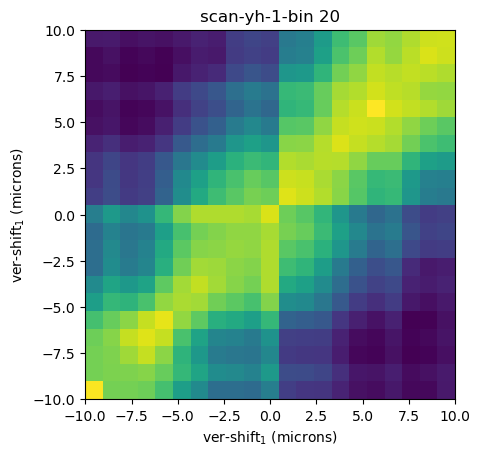

In [57]:
figure()
binno=20 #16+8+2+4
plt.imshow(res[binno,:,:],extent=[-10,10,-10,10])
print(qavg[binno],phiavg[binno])
plt.xlabel("ver-shift$_1$ (microns)")
plt.ylabel("ver-shift$_1$ (microns)" )
plt.title("{:s}-bin {:d}".format(DD.DD['FOUT'],binno))
plt.savefig("plots/{:s}-twoshifts.pdf".format(DD.DD['FOUT']))
plt.savefig("/tmp/g2-twoy.pdf")

<Figure size 640x480 with 0 Axes>

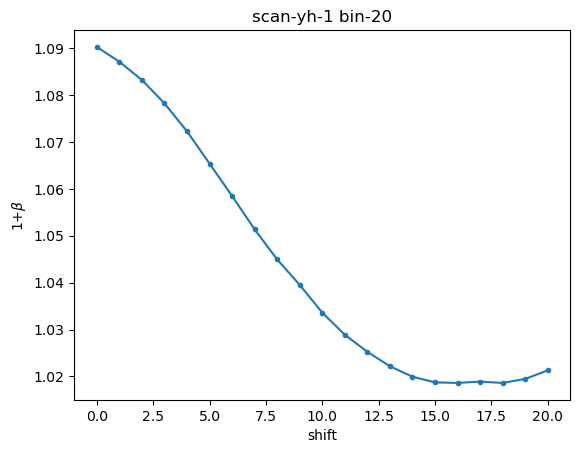

In [56]:
figure()
g2=avgg2(res[binno,:,:])
plot(g2,'.-')
plt.xlabel("shift")
plt.ylabel(r"1+$\beta$")
plt.title("{:s} bin-{:d}".format(DD.DD['FOUT'],binno))
plt.savefig("/tmp/g2-y.pdf")

<Figure size 640x480 with 0 Axes>